In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
path = "/content/drive/MyDrive/praktikum_ml/praktikum04/data/calonpembelimobil.csv"

In [24]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, RocCurveDisplay
)

In [25]:
df = pd.read_csv(path)
df.head()

,ID,Usia,Status,Kelamin,Memiliki_Mobil,Penghasilan,Beli_Mobil
0,1,32,1,0,0,240,1
1,2,49,2,1,1,100,0
2,3,52,1,0,2,250,1
3,4,26,2,1,1,130,0
4,5,45,3,0,2,237,1


In [26]:
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ID              1000 non-null   int64
 1   Usia            1000 non-null   int64
 2   Status          1000 non-null   int64
 3   Kelamin         1000 non-null   int64
 4   Memiliki_Mobil  1000 non-null   int64
 5   Penghasilan     1000 non-null   int64
 6   Beli_Mobil      1000 non-null   int64
dtypes: int64(7)
memory usage: 54.8 KB


,0
ID,0
Usia,0
Status,0
Kelamin,0
Memiliki_Mobil,0
Penghasilan,0
Beli_Mobil,0


In [28]:
print("Unique values in 'Status':", df['Status'].unique())
print("Unique values in 'Kelamin':", df['Kelamin'].unique())
print("Unique values in 'Memiliki_Mobil':", df['Memiliki_Mobil'].unique())
print("Unique values in 'Beli_Mobil':", df['Beli_Mobil'].unique())

Unique values in 'Status': [1 2 3 0]
Unique values in 'Kelamin': [0 1]
Unique values in 'Memiliki_Mobil': [0 1 2 4 3]
Unique values in 'Beli_Mobil': [1 0]


In [30]:
X = df[['Status', 'Kelamin', 'Memiliki_Mobil']]
y = df['Beli_Mobil']

X.head(), y.head()

(   Status  Kelamin  Memiliki_Mobil
 0       1        0               0
 1       2        1               1
 2       1        0               2
 3       2        1               1
 4       3        0               2,
 0    1
 1    0
 2    1
 3    0
 4    1
 Name: Beli_Mobil, dtype: int64)

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

Data training: (800, 3)
Data testing : (200, 3)


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('scaler', StandardScaler()),        # normalisasi data numerik
    ('logreg', LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42))
])

model.fit(X_train, y_train)
print("Model Logistic Regression berhasil dilatih.")

Model Logistic Regression berhasil dilatih.


=== Evaluasi Model Logistic Regression ===
Akurasi : 0.64
Presisi : 0.6571428571428571
Recall  : 0.905511811023622
F1-Score: 0.7615894039735099


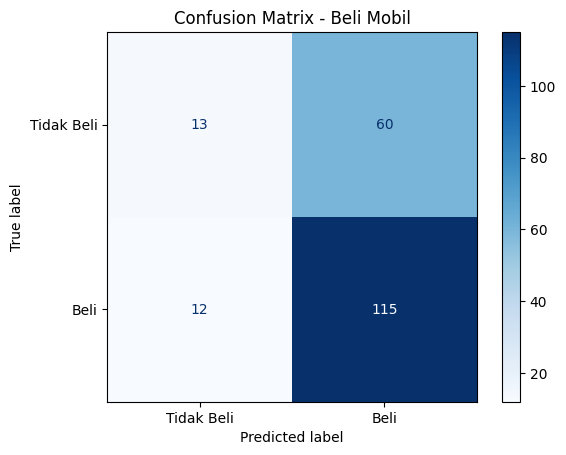

In [33]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
)

y_pred = model.predict(X_test)

print("=== Evaluasi Model Logistic Regression ===")
print("Akurasi :", accuracy_score(y_test, y_pred))
print("Presisi :", precision_score(y_test, y_pred))
print("Recall  :", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

# Visualisasi confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=['Tidak Beli', 'Beli']).plot(cmap='Blues')
plt.title('Confusion Matrix - Beli Mobil')
plt.show()

In [34]:
data_baru = pd.DataFrame({
    'Status': [1],
    'Kelamin': [1],
    'Memiliki_Mobil': [0]
})

pred = model.predict(data_baru)
prob = model.predict_proba(data_baru)[:, 1]

print("Data Baru:", data_baru)
print("Probabilitas Beli Mobil:", prob[0])
print("Prediksi:", "Beli Mobil" if pred[0]==1 else "Tidak Beli Mobil")

Data Baru:    Status  Kelamin  Memiliki_Mobil
0       1        1               0
Probabilitas Beli Mobil: 0.4760986979466275
Prediksi: Tidak Beli Mobil
